In [1]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_motivation_x_progression" # change this to the subfolder it should save to

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"
import numpy as np
import pandas as pd

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

# if date == "20210404":
#     marks_group_name = "mpfc1"
# else:
#     marks_group_name = "mpfc"

marks_group_name = "mpfc sorted spikes"
marks_group_name = "mpfc"
marks_group_name = "mpfc_HYBRID"
model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}

if "sorted_spikes" in marks_group_name:
    checkpoint = None
else:
    checkpoint = 6
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=checkpoint)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-10-02 09:25:18,046][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-10-02 09:25:37.148524: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-02 09:25:38.454827: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-02 09:25:40.465322: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-10-02 09:25:53,618][WARNING]: Skipped checksum for file

In [3]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]


t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
# analysis.embed_context_pca()
analysis.fit_context_pca(fit_intervals = run_epochs)

# Load Data

### Trial and decoding dataframes

In [4]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[09:29:32][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[09:29:32][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

### Position Data

In [5]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


### Sorted Spikes

In [6]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes, unit_ids = (spikes_query).fetch_spike_data(spikes_key, return_unit_ids=True)
unit_ids = np.array([f"{u['spikesorting_merge_id']}_{u['unit_id']}" for u in unit_ids])

[09:31:02][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

## Monosynaptic

In [7]:
import os
os.chdir("/home/sambray/Documents/spyglass_custom/src/spyglass_custom/sambray")
from monosynaptic import Monosynaptic
from cross_correlogram import CrossCorrelogram, ShuffleCrossCorrelogram

cross_corr_key = {"cross_corr_params_name":"monosynaptic"}

mono_key = (Monosynaptic & spikes_key & {"monosynaptic_params_name": "default"}).fetch1("KEY")
neuron_types = (Monosynaptic & mono_key).get_neuron_types()
mono_df = (Monosynaptic & mono_key).fetch1_dataframe()

corr_df = (CrossCorrelogram & mono_key).fetch1_dataframe()
shuffle_corr_df = (ShuffleCrossCorrelogram & spikes_key).fetch1_dataframe()
corr_df = corr_df.merge(shuffle_corr_df, on=["unit_id_1", "unit_id_2"], suffixes=("", "_shuffle"))
ind_neuron_type = {}
for type_, ids_ in neuron_types.items():
    ind_neuron_type[type_] = [np.where(unit_ids == i)[0][0] for i in ids_]
neuron_colors = {
    "excitatory": "cornflowerblue",
    "inhibitory":"firebrick"
}

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manage

# Embedding

In [8]:
motivation_pcs = (0,2)

# analysis.params['params']['embedding']['encoder']['encoder_matrix'].shape
param_source = analysis.params['params']['embedding']['encoder']
if "sorted_encoder" in param_source:
    param_source = param_source["sorted_encoder"]
W = param_source["encoder_matrix"]
W = W @ analysis.pca.components_.T

trial_mot_pcs = []
for trial in trial_df.itertuples():
    st = trial.run_start-.5
    en = trial.t_poke + .5
    ind_st = np.searchsorted(t_interp, st)
    ind_en = np.searchsorted(t_interp, en)
    trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, motivation_pcs].mean(axis=0))
trial_mot_pcs = np.array(trial_mot_pcs)
trial_mot_angle = np.arctan2(trial_mot_pcs[:,0], -trial_mot_pcs[:,1])
# plt.scatter(trial_mot_pcs[:,0], trial_mot_pcs[:,1], c=trial_df.prev_trial_reward, cmap=plt.cm.coolwarm, alpha=0.5)
trial_df["motivation"] = trial_mot_angle

/tmp/ipykernel_24639/111306566.py:16: RuntimeWarning: Mean of empty slice.
  trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, motivation_pcs].mean(axis=0))


# Motivation Angle + Reward Rate Scatter

In [10]:
mot_pc_vals = []
trial_rate = []
reward_rate = []
t_bin = []
epoch_bin = []

bin_size = 60.0 # seconds
bin_step = 5.0 # seconds
dt = .001

ind_size = int(bin_size/dt)
ind_step = int(bin_step/dt)
from tqdm import tqdm
for i_ep, (st, en) in tqdm(enumerate(run_epochs)):
    st = st+60
    en = en-60
    epoch_interval = [st, en]
    ind_epoch = interval_list_contains_ind(np.array([epoch_interval]), analysis.t_interp)
    st = ind_epoch[0]#+60
    while st < ind_epoch[-1]:
        en = st + ind_size
        if en > ind_epoch[-1]:
            break
        t_st = analysis.t_interp[st]
        t_en = analysis.t_interp[en]
        if t_en > epoch_interval[1]:
            break
        t_bin.append((t_st+t_en)/2)
        mot_pc_vals.append(np.mean(analysis.c_pca_interp[st:en, motivation_pcs], axis=0))

        ind_trial = np.where((trial_df["t_poke"] >= t_st) & (trial_df["t_poke"] < t_en))[0]
        trial_rate.append(len(ind_trial)/bin_size*60)
        n_rewards = np.sum(trial_df["reward"].iloc[ind_trial])
        reward_rate.append(n_rewards/bin_size*60)
        epoch_bin.append(i_ep)

        st += ind_step

mot_pc_vals = np.array(mot_pc_vals)
trial_rate = np.array(trial_rate)
reward_rate = np.array(reward_rate)
epoch_bin = np.array(epoch_bin)
t_bin = np.array(t_bin)

5it [00:02,  1.85it/s]


Text(0, 0.5, 'Trial Rate ($min^{-1}$)')

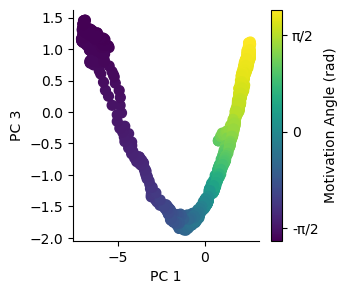

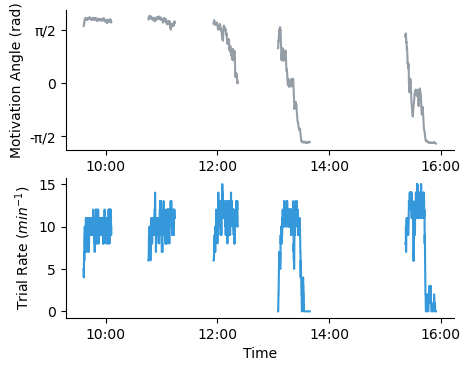

In [12]:
from datetime import datetime
mot_angle = np.arctan2(mot_pc_vals[:,0], -mot_pc_vals[:,1])

fig1 = plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.spines[["top", "right"]].set_visible(False)
plt.scatter(mot_pc_vals[:,0], mot_pc_vals[:,1], c=mot_angle, cmap="viridis", s=50)
plt.xlabel(f"PC {motivation_pcs[0]+1}")
plt.ylabel(f"PC {motivation_pcs[1]+1}")
cb = plt.colorbar(label="Motivation Angle (rad)")
cb.ax.set_yticks([ -np.pi/2, 0, np.pi/2,],)
cb.ax.set_yticklabels([ "-π/2", "0", "π/2"])



#
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(211)
ax_trial = fig.add_subplot(212, sharex=ax)
ax.spines[["top", "right"]].set_visible(False)
ax_trial.spines[["top", "right"]].set_visible(False)
# ax.scatter(t_bin, mot_angle)
for i in np.unique(epoch_bin):
    ind = np.where(epoch_bin == i)[0]
    ax.plot(t_bin[ind], mot_angle[ind], color="#2c3e50", alpha=0.5)
ax.set_yticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])
dt = datetime.fromtimestamp(t_bin[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]
ax.set_xticks(tick_times, tick_labels)
plt.xlabel("Time")
ax.set_ylabel("Motivation Angle (rad)")

# ax_trial.scatter(t_bin, trial_rate, color="#3498db", alpha=0.5, s=20)
for i in np.unique(epoch_bin):
    ind = np.where(epoch_bin == i)[0]
    ax_trial.plot(t_bin[ind], trial_rate[ind], color="#3498db")
ax_trial.set_ylabel("Trial Rate ($min^{-1}$)")

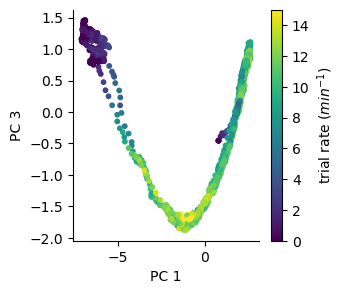

In [14]:
fig1 = plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.spines[["top", "right"]].set_visible(False)
plt.scatter(mot_pc_vals[:,0], mot_pc_vals[:,1], c=trial_rate, cmap="viridis", s=10)
plt.xlabel(f"PC {motivation_pcs[0]+1}")
plt.ylabel(f"PC {motivation_pcs[1]+1}")
cb = plt.colorbar(label="trial rate ($min^{-1}$)")
# cb.ax.set_yticks([ -np.pi/2, 0, np.pi/2,],)
# cb.ax.set_yticklabels([ "-π/2", "0", "π/2"])

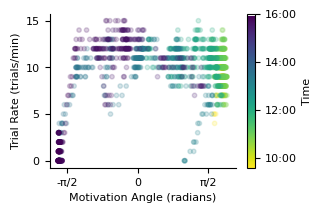

In [24]:
fig = plt.figure(figsize=(3,2))
ax = fig.add_subplot(111)
plt.rcParams["font.size"] = 8
plt.rcParams['svg.fonttype'] = 'none'
plt.scatter(mot_angle, trial_rate, c=t_bin, cmap="viridis_r", s=10, alpha = .2)

plt.xlabel("Motivation Angle (radians)")
plt.ylabel("Trial Rate (trials/min)")
cb = plt.colorbar(label="Time")

from datetime import datetime
st = datetime.fromtimestamp(t_bin[10])
en = datetime.fromtimestamp(t_bin[-1])

dt = datetime.fromtimestamp(t_bin[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]

cb.ax.set_yticks(tick_times)
cb.ax.set_yticklabels(tick_labels)
# `cb.solids_patches` is a list in newer matplotlib versions, so set alpha on the actual artist(s)
for collection in cb.ax.collections:
    collection.set_alpha(1)

ax.set_xticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])
ax.spines[["top", "right"]].set_visible(False)
# plt.xscale("log")
plt.savefig(fig_dir / f"motivation_angle_x_trial_rate.svg", dpi=300, bbox_inches="tight")

## Neuron joint progression motivation scatter

In [25]:
prog_pcs = (1, 3)

w_prog = W[:, prog_pcs]
w_prog_mag = np.linalg.norm(w_prog, axis=1)

w_mot = W[:, motivation_pcs]
w_mot_mag = np.linalg.norm(w_mot, axis=1)

thresh = .2
ind = np.where(np.logical_and(w_prog_mag > thresh, w_mot_mag > thresh))[0]
ind.size
ind

array([ 26,  51,  58,  95, 101, 103, 124, 168, 184, 186, 274, 375, 422,
       451, 465])

In [12]:
neurons_to_plot = [189,488,196 ,425]

neuron_id = 189
neuron_id = ind[1]

In [13]:
# mark_list = [ "run_start", "t_choice", "t_poke", ]
# offset_list = [ -.5, 1.25, 2.5, ]
# range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

mark_set = "B"
if mark_set == "A":
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25, 2.5, ]
    range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]
elif mark_set == "B":
    mark_list = [ "run_start", "t_choice", ]
    offset_list = [ -.5, 1.25,  ]
    range_list = [ (-1, 1), (-0.5, 1),]
else:
    raise ValueError(f"mark_set {mark_set} not recognized. Must be 'A' or 'B'")


xx = []
yy = []
cc = []
for i, trial in enumerate(trial_df.itertuples()):
    c = "dodgerblue" if trial.prev_trial_reward == 1 else "firebrick"

    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        t_mark = getattr(trial, mark)
        t_start = t_mark + rng[0]
        t_end = t_mark + rng[1]
        ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
        ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

        xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
        yy.extend(np.ones(len(ind_neuron))*i)
        cc.extend([c]*len(ind_neuron))
        # if len(ind_neuron) > 0:
        #     plt.scatter(spikes[neuron_id][ind_neuron]-t_mark +offset, np.ones(len(ind_neuron))*i, color="k",
        #                 s=5, alpha=1, marker = "|")

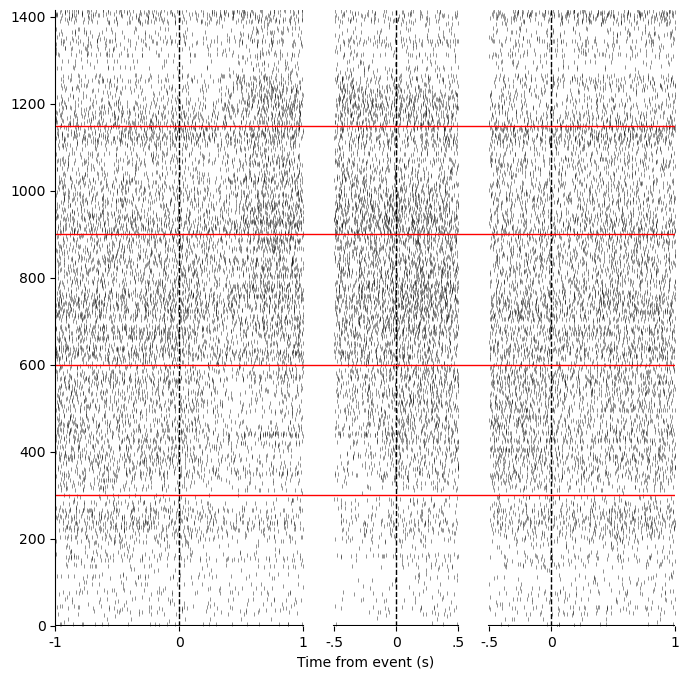

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)


# plt.scatter(xx, yy, s=5, marker = "|",lw=.5,alpha=.7,c = cc)
plt.scatter(xx, yy, s=5, marker = "|",lw=.5,alpha=.6,color='k')
trial_epoch = trial_df["epoch"].values

ax.set_ylim(0, len(trial_df))
ylim = ax.get_ylim()
ticks = []
labels = []
for mark, offset, rng in zip(mark_list, offset_list, range_list):
    lo = -1 if rng[0] < -.75 else rng[0]
    hi = 1 if rng[1] > 1 else rng[1]
    lo_txt = "-.5" if lo == -0.5 else "-1"
    hi_txt = ".5" if hi == 0.5 else "1"

    xx_ = np.array([lo, 0, hi])
    ticks.append(xx_ + offset)
    labels.append([lo_txt, "0", hi_txt])
    ax.plot(xx_ + offset, [ylim[0]] * len(xx_), color="k")
    ax.axvline(offset, color="k", lw=1, ls="--")
ticks = np.concatenate(ticks)
labels = np.concatenate(labels)
ax.set_xticks(ticks, labels)
ax.set_xlabel("Time from event (s)")
ind_switch = np.where(trial_epoch[1:] != trial_epoch[:-1])[0]+1
for i in ind_switch:
    plt.axhline(i, color="r", alpha=1, lw=1)

ax.set_ylim(ylim)
ax.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
ax.spines[["top", "right","bottom"]].set_visible(False)

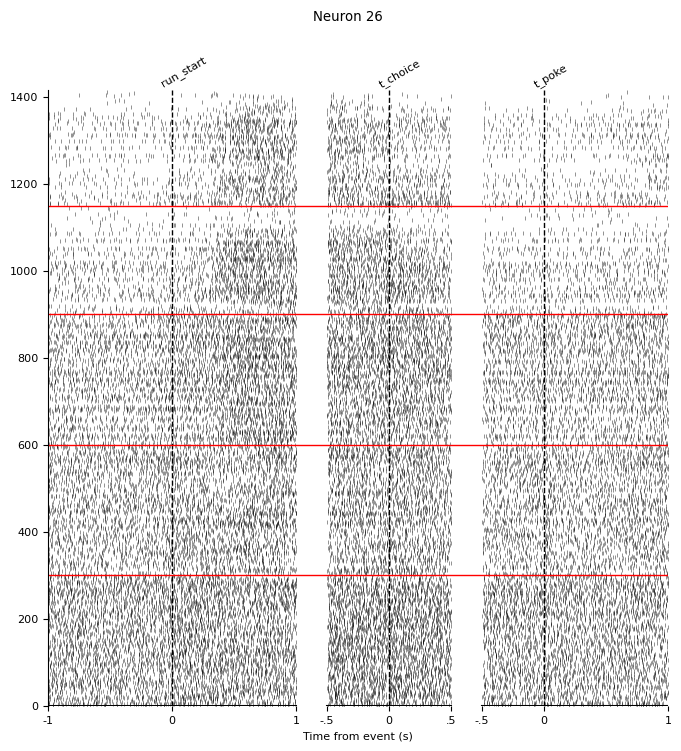

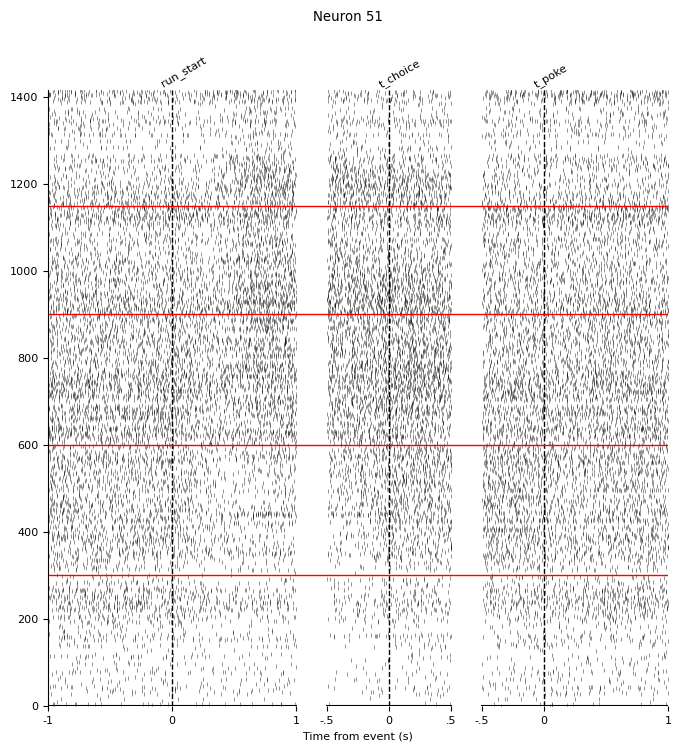

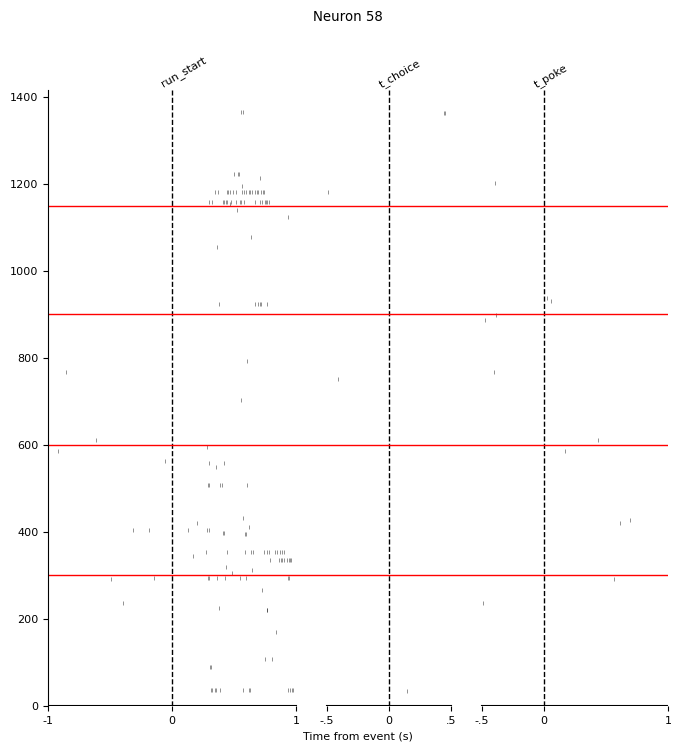

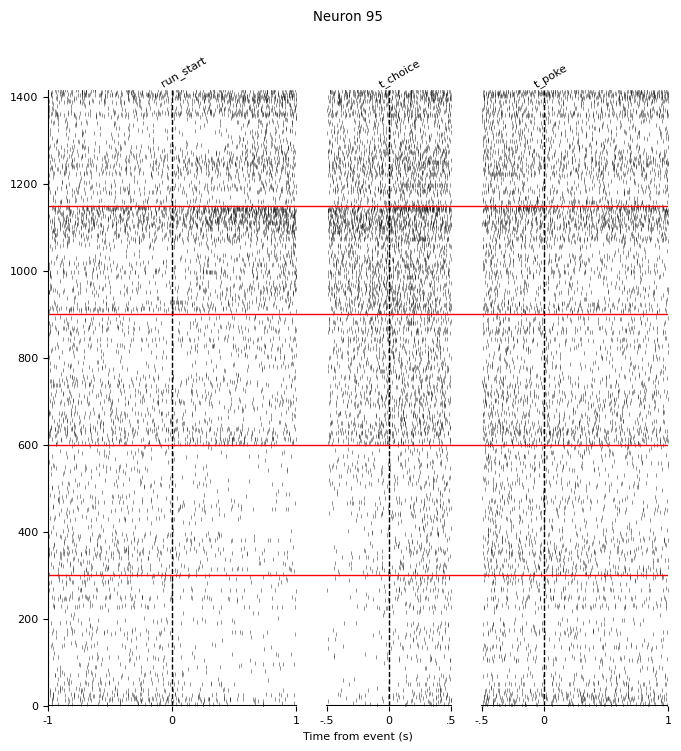

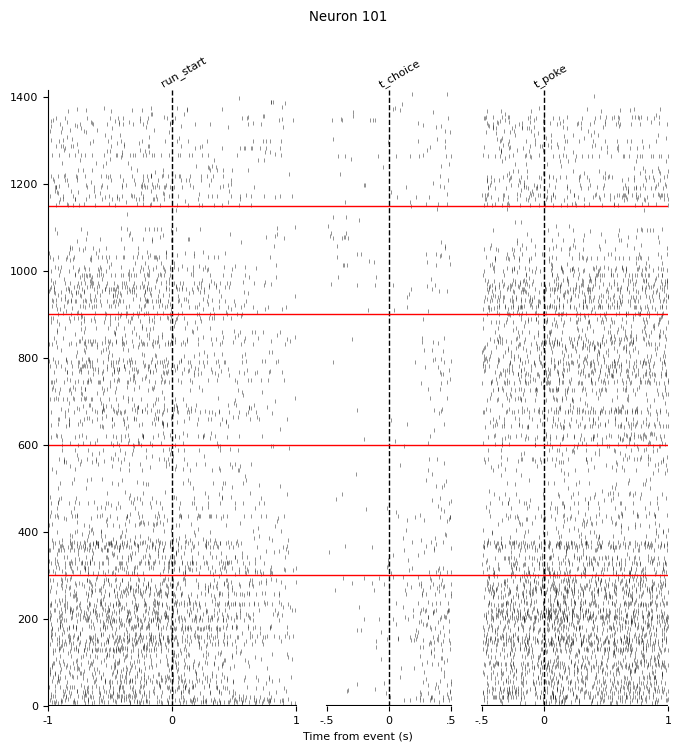

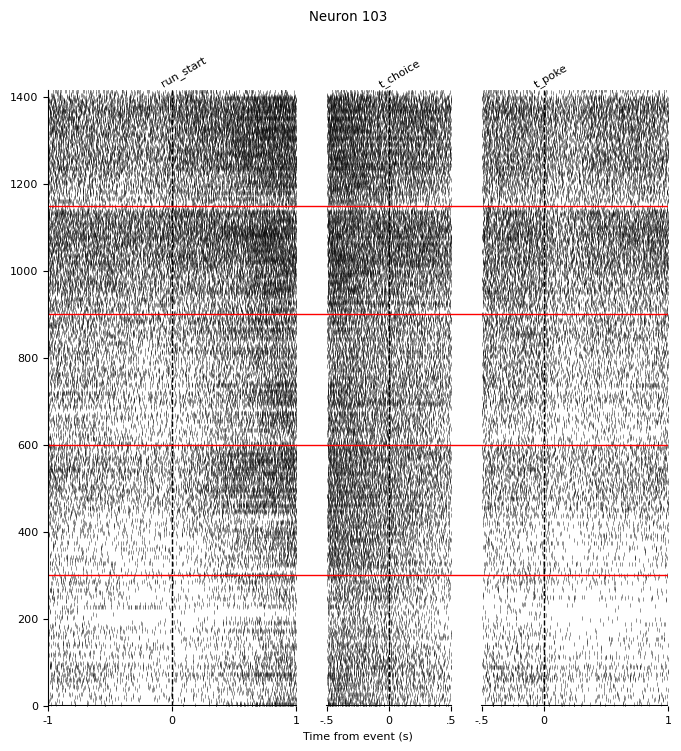

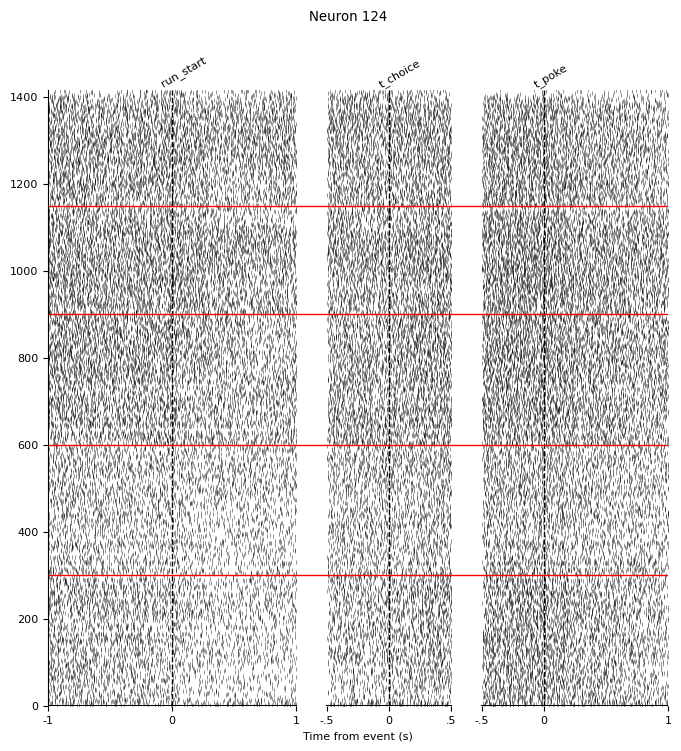

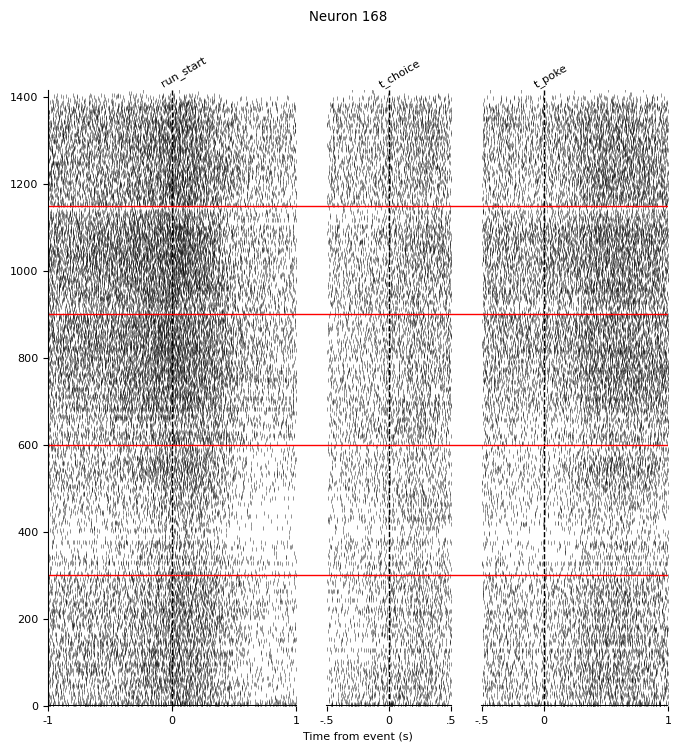

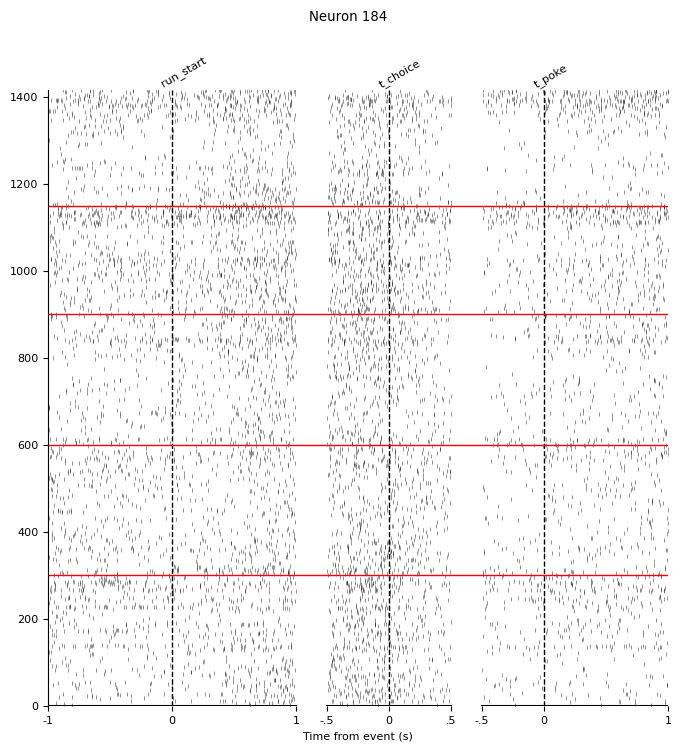

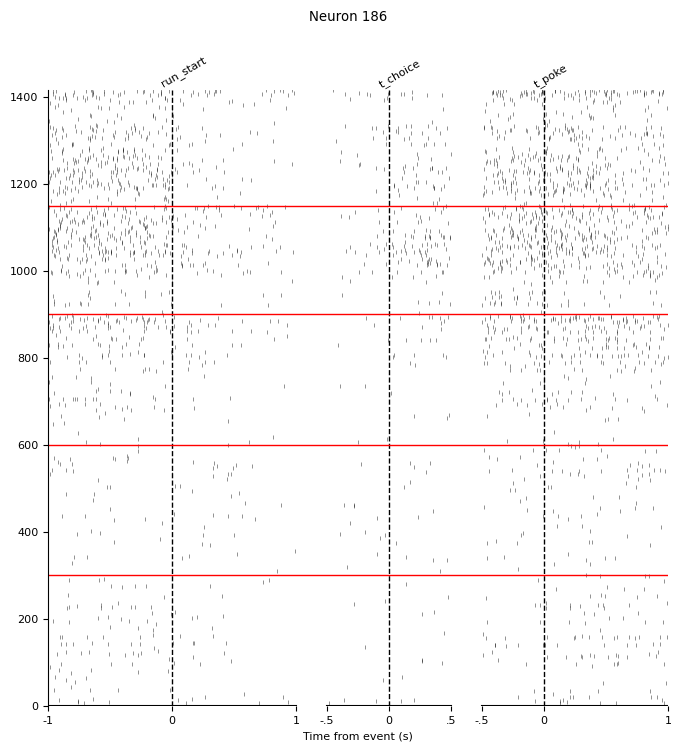

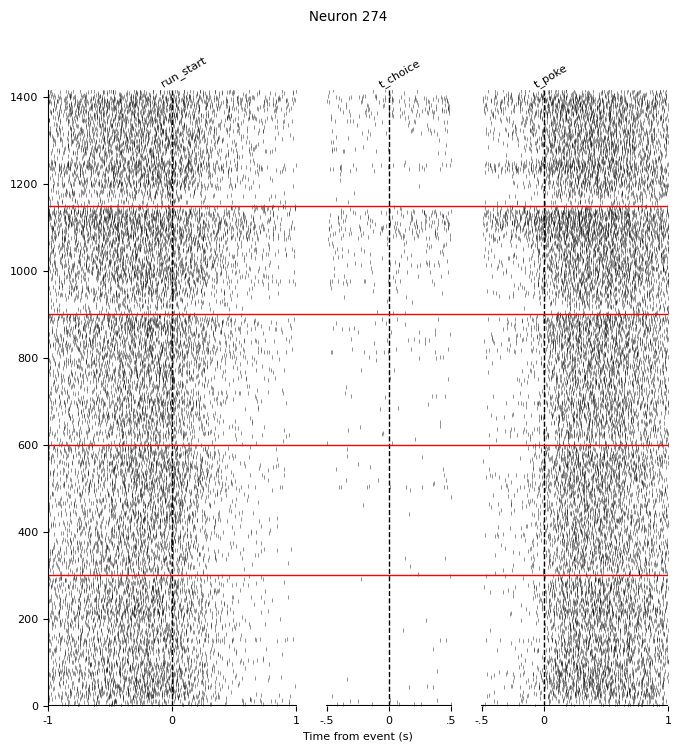

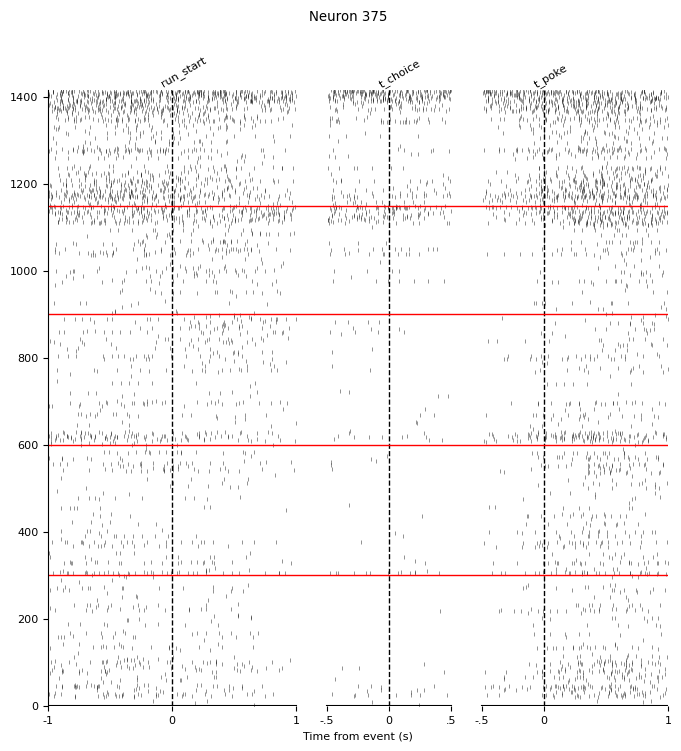

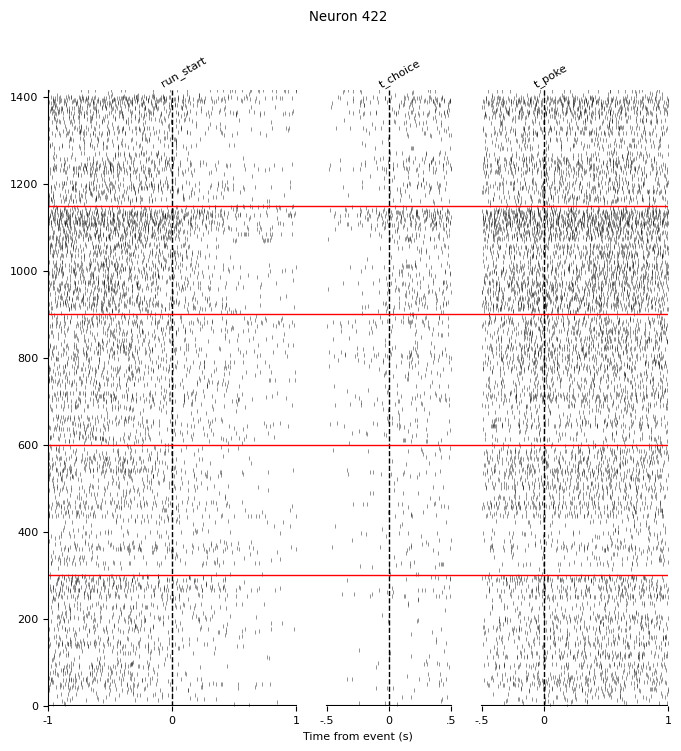

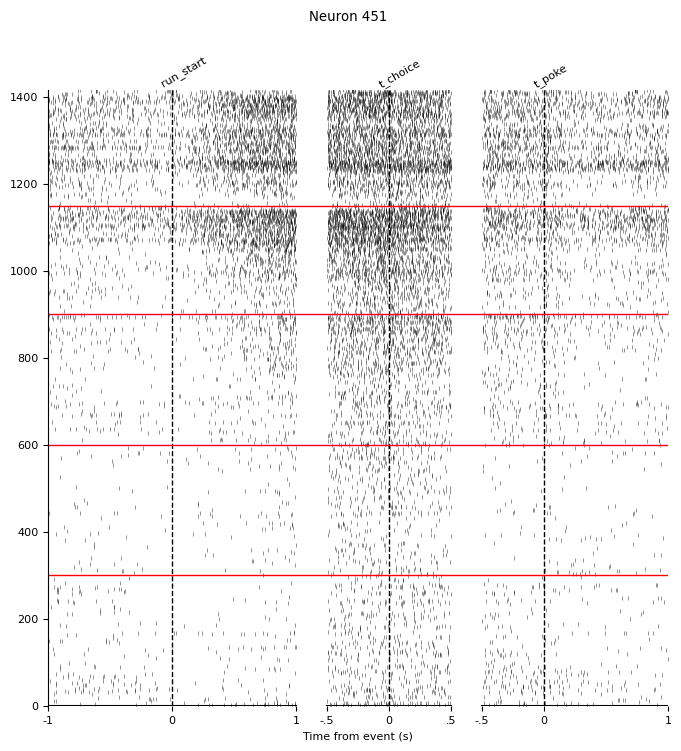

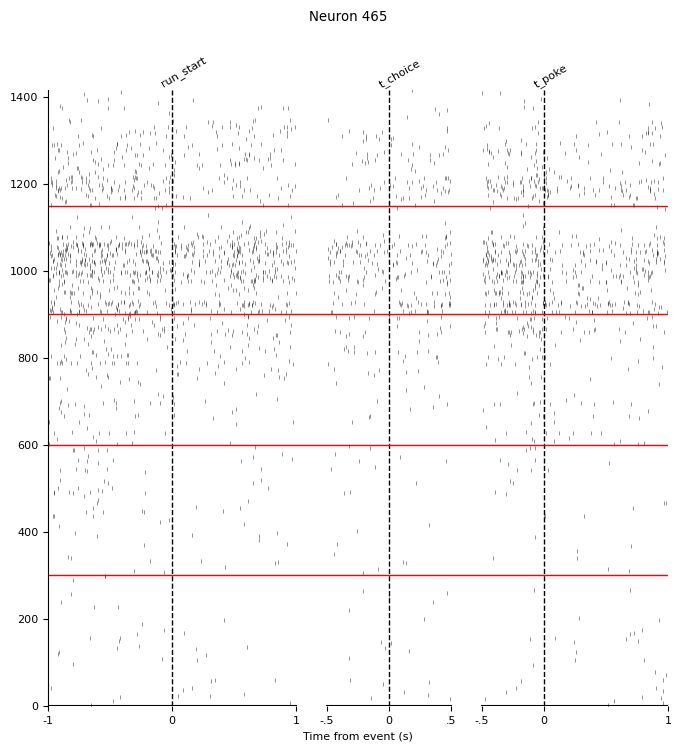

In [26]:
prog_pcs = (1, 3)

w_prog = W[:, prog_pcs]
w_prog_mag = np.linalg.norm(w_prog, axis=1)

w_mot = W[:, motivation_pcs]
w_mot_mag = np.linalg.norm(w_mot, axis=1)

thresh = .2
ind = np.where(np.logical_and(w_prog_mag > thresh, w_mot_mag > thresh))[0]

for neuron_id in ind:
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25, 2.5, ]
    range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

    xx = []
    yy = []
    cc = []
    for i, trial in enumerate(trial_df.itertuples()):
        c = "dodgerblue" if trial.prev_trial_reward == 1 else "firebrick"

        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            t_mark = getattr(trial, mark)
            t_start = t_mark + rng[0]
            t_end = t_mark + rng[1]
            ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
            ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

            xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
            yy.extend(np.ones(len(ind_neuron))*i)
            cc.extend([c]*len(ind_neuron))

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)


    # plt.scatter(xx, yy, s=5, marker = "|",lw=.5,alpha=.7,c = cc)
    plt.scatter(xx, yy, s=5, marker = "|",lw=.5,alpha=.6,color='k')
    trial_epoch = trial_df["epoch"].values

    ax.set_ylim(0, len(trial_df))
    ylim = ax.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx_ = np.array([lo, 0, hi])
        ticks.append(xx_ + offset)
        labels.append([lo_txt, "0", hi_txt])
        ax.plot(xx_ + offset, [ylim[0]] * len(xx_), color="k")
        ax.axvline(offset, color="k", lw=1, ls="--")

        ax.text(offset - .1, ylim[1], mark, ha="left", va="bottom", rotation=30)


    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    ax.set_xticks(ticks, labels)
    ax.set_xlabel("Time from event (s)")
    ind_switch = np.where(trial_epoch[1:] != trial_epoch[:-1])[0]+1
    for i in ind_switch:
        plt.axhline(i, color="r", alpha=1, lw=1)

    ax.set_ylim(ylim)
    ax.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
    ax.spines[["top", "right","bottom"]].set_visible(False)
    fig.suptitle(f"Neuron {neuron_id}")

### Ordered by motivation angle

In [27]:
# angles = []
# trial_mot_pcs = []
# for i, trial in enumerate(trial_df.itertuples()):
#     t_st = trial.run_start - 1.0
#     t_en = trial.t_poke + 1.0
#     st_c = np.digitize(t_st, analysis.t_interp)
#     en_c = np.digitize(t_en, analysis.t_interp)
#     c_mot = np.mean(analysis.c_pca_interp[st_c:en_c, motivation_pcs], axis=0)
#     angle_mot = np.arctan2(c_mot[0], -c_mot[1])
#     angles.append(angle_mot)
#     trial_mot_pcs.append(c_mot)

# angles = np.array(angles)
# trial_mot_pcs = np.array(trial_mot_pcs)

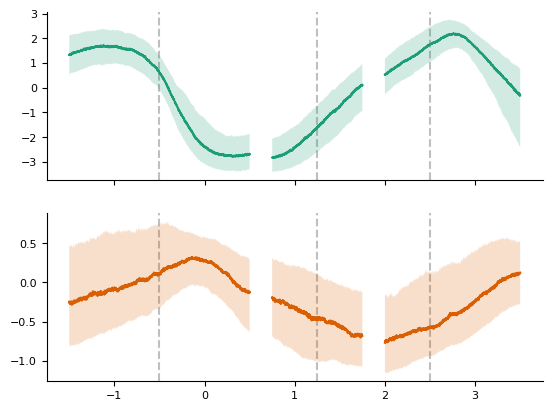

In [28]:
fig, trial_pc_ax = plt.subplots(nrows=2,sharex=True)

cached_results = {}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    # for group, label, color in zip(condition_groups, condition_labels, condition_colors):
    mark_times = trial_df[mark].values
    if len(mark_times) == 0:
        continue

    if mark in cached_results:
        results = cached_results[mark]
    else:
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        cached_results[mark] = results

    r = np.nanpercentile(results, [25, 50, 75], axis=0)
    mid = r[1]
    lo = r[0]
    hi = r[2]

    t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
    ind_mid = np.digitize(offset,t_plot)
    for i, ax_i in enumerate(trial_pc_ax):
        # ax = fig.gca()
        color = plt.cm.Dark2(i/8)
        pc = prog_pcs[i]
        ax_i.plot(t_plot,mid[:, pc], color=color)
        ax_i.fill_between(t_plot, lo[:,pc], hi[:,pc], facecolor=color, alpha=0.2)
        ax_i.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

        ax_i.spines[["top", "right"]].set_visible(False)

In [29]:
neuron_id = 451
neuron_id = 26
neuron_id = 274
neuron_id = 103

mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -.5, 1.25, 2.5, ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

xx_all = []
yy_all = []
cc_all = []
angles = []
# angles = []
for i, trial in enumerate(trial_df.itertuples()):
    c = "dodgerblue" if trial.prev_trial_reward == 1 else "firebrick"
    # t_st = trial.run_start - 1.0
    # t_en = trial.t_poke + 1.0
    # st_c = np.digitize(t_st, analysis.t_interp)
    # en_c = np.digitize(t_en, analysis.t_interp)
    # c_mot = np.mean(analysis.c_pca_interp[st_c:en_c, motivation_pcs], axis=0)
    # angle_mot = np.arctan2(c_mot[0], -c_mot[1])
    # angles.append(angle_mot)
    angles.append(trial.motivation)
    xx = []
    yy = []
    cc = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        t_mark = getattr(trial, mark)
        t_start = t_mark + rng[0]
        t_end = t_mark + rng[1]
        ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
        ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

        xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
        yy.extend(np.ones(len(ind_neuron)))
        cc.extend([c]*len(ind_neuron))

    xx_all.append(xx)
    yy_all.append(yy)
    cc_all.append(cc)

        # if len(ind_neuron) > 0:
        #     plt.scatter(spikes[neuron_id][ind_neuron]-t_mark +offset, np.ones(len(ind_neuron))*i, color="k",
        #                 s=5, alpha=1, marker = "|")

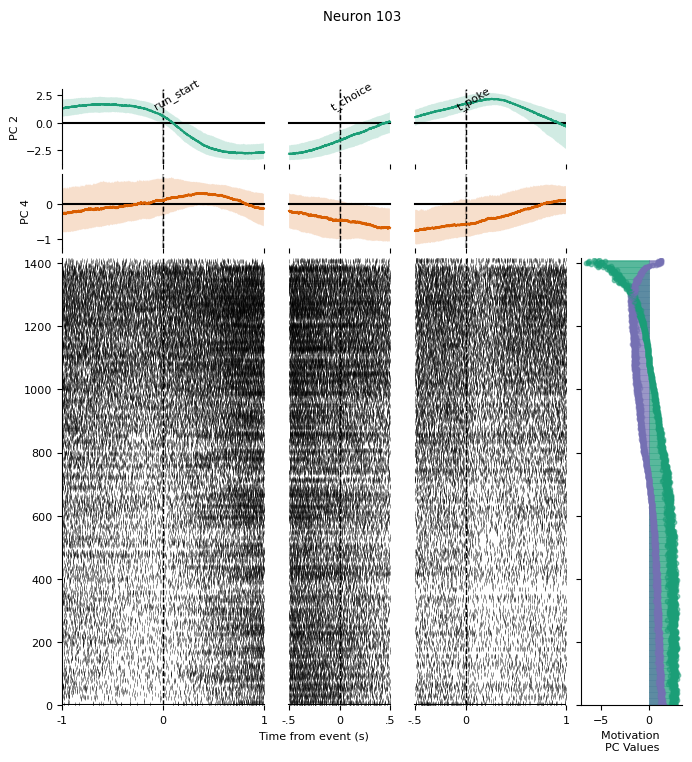

In [30]:
angle_sort = np.argsort(-np.array(angles))

fig, ax_list = plt.subplots(figsize=(8,8),ncols=2,nrows=3, width_ratios=[5,1], sharey='row',
                            sharex='col',height_ratios=[1,1,6], gridspec_kw={'hspace':0.05, 'wspace':0.05})

ax = ax_list[2,0]
pc_ax = ax_list[2,1]
trial_pc_ax = ax_list[0:2,0]

xx_plot = []
yy_plot = []
for i, trial in enumerate(angle_sort):
    xx = xx_all[trial]
    yy = yy_all[trial]
    # cc = cc_all[trial]
    xx_plot.extend(xx)
    yy_plot.extend(np.array(yy)+i)

    for j in range(2):
        v = trial_mot_pcs[trial][j]
        c = plt.cm.Dark2(motivation_pcs[j]/8)
        pc_ax.scatter(v, i, s=10, color=c, alpha=.5)
        pc_ax.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)

ax.scatter(xx_plot, yy_plot, s=5, marker = "|",lw=.5,alpha=.6,color='k')

ax.set_ylim(0, len(trial_df))

for i_a, a in enumerate(ax_list[:,0]):
    a.spines[["top", "right","bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx_ = np.array([lo, 0, hi])
        ticks.append(xx_ + offset)
        labels.append([lo_txt, "0", hi_txt])

        a.plot(xx_ + offset, [ylim[0]] * len(xx_), color="k")
        a.axvline(offset, color="k", lw=1, ls="--")
        if i_a == 0:
            a.text(offset - .1, ylim[1], mark, ha="left", va="bottom", rotation=30)


ticks = np.concatenate(ticks)
labels = np.concatenate(labels)
ax.set_xticks(ticks, labels)
ax.set_xlabel("Time from event (s)")

ax.set_ylim(ylim)
ax.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
ax.spines[["top", "right","bottom"]].set_visible(False)
pc_ax.spines[["top", "right",]].set_visible(False)
fig.suptitle(f"Neuron {neuron_id}")
pc_ax.set_xlabel("Motivation \nPC Values")


# cached_results = {}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    # for group, label, color in zip(condition_groups, condition_labels, condition_colors):
    mark_times = trial_df[mark].values
    if len(mark_times) == 0:
        continue

    if mark in cached_results:
        results = cached_results[mark]
    else:
        results = analysis.alligned_response(mark_times, range_val, pca=True)
        cached_results[mark] = results

    r = np.nanpercentile(results, [25, 50, 75], axis=0)
    mid = r[1]
    lo = r[0]
    hi = r[2]

    t_plot = np.linspace(range_val[0], range_val[1], len(mid)) + offset
    ind_mid = np.digitize(offset,t_plot)
    for i, ax_i in enumerate(trial_pc_ax):
        # ax = fig.gca()
        color = plt.cm.Dark2(i/8)
        pc = prog_pcs[i]
        ax_i.plot(t_plot,mid[:, pc], color=color)
        ax_i.fill_between(t_plot, lo[:,pc], hi[:,pc], facecolor=color, alpha=0.2)
        ax_i.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)

        ax_i.spines[["top", "right"]].set_visible(False)
        ax_i.set_ylabel(f"PC {pc+1}")

for a in ax_list[:2,1]:
    a.set_axis_off()

# Combined Publication figure

In [16]:
neuron_id = 451
# neuron_id = 26
# neuron_id = 274
# neuron_id = 103
# neuron_id = 475
# neuron_id = 2
# neuron_id = 8
# neuron_id = 212
# neuron_id = 64
# neuron_id = 7

# mark_list = [ "run_start", "t_choice", "t_poke", ]
# offset_list = [ -.5, 1.25, 2.5, ]
# range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]
mark_set = "B"
if mark_set == "A":
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25, 2.5, ]
    range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]
elif mark_set == "B":
    mark_list = [ "run_start", "t_choice", ]
    offset_list = [ -.5, 1.25,  ]
    range_list = [ (-1, 1), (-0.5, 1),]
else:
    raise ValueError(f"mark_set {mark_set} not recognized. Must be 'A' or 'B'")


xx_all = []
yy_all = []
cc_all = []
angles = []

for i, trial in enumerate(trial_df.itertuples()):
    angles.append(trial.motivation)
    xx = []
    yy = []
    cc = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        t_mark = getattr(trial, mark)
        t_start = t_mark + rng[0]
        t_end = t_mark + rng[1]
        ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
        ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

        xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
        yy.extend(np.ones(len(ind_neuron)))
        cc.extend([c]*len(ind_neuron))

    xx_all.append(xx)
    yy_all.append(yy)
    cc_all.append(cc)

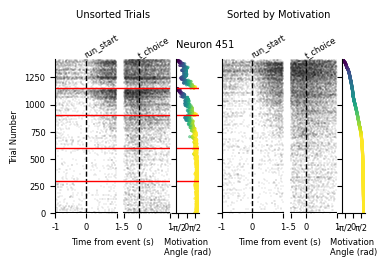

In [ ]:
angle_sort = np.argsort(-np.array(angles))

if mark_set == "A":
    figsize = (8,4)
    spike_marker_kwargs = dict(s=1, marker = "|",lw=.25,alpha=.6,color='k', rasterized=True)
elif mark_set == "B":
    figsize = (4,2)
    plt.rcParams["font.size"] = 6
    spike_marker_kwargs = dict(s=1, marker = "|",lw=.2,alpha=.4,color='k', rasterized=True)

fig, ax_list = plt.subplots(figsize=figsize,ncols=5,nrows=1, width_ratios=[5,1,.5,5,1], sharey='row',
                            sharex='col',height_ratios=[1,], gridspec_kw={'hspace':0.05, 'wspace':0.1})


pc_marker_kwargs = dict(s=3, marker = "o",lw=.5,alpha=.6, rasterized=True)

# ax_sorted = ax_list[2]
# ax_unsorted = ax_list[0]
# pc_ax_sorted = ax_list[3]
# pc_ax_unsorted = ax_list[1]
ax_sorted = ax_list[3]
ax_unsorted = ax_list[0]
pc_ax_sorted = ax_list[4]
pc_ax_unsorted = ax_list[1]
ax_list[2].set_axis_off()


xx_plot = []
yy_plot = []
yy_unsorted = []
xx_unsorted = []
for i, trial in enumerate(angle_sort):
    xx = xx_all[trial]
    yy = yy_all[trial]
    # cc = cc_all[trial]
    if not np.isnan(angles[trial]):
        xx_plot.extend(xx)
        yy_plot.extend(np.array(yy)+i)
    yy_unsorted.extend(np.array(yy)+trial)
    xx_unsorted.extend(xx)
    # v = angles[trial]
    # c = plt.cm.viridis((v+np.pi/2)/np.pi)
    # pc_ax_sorted.scatter(v, i, s=10, color=c, alpha=.5)
    # pc_ax_sorted.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)
    # pc_ax_unsorted.scatter(v, trial, s=10, color=c, alpha=.5)
    # pc_ax_unsorted.plot([0, v], [trial, trial], color=c, alpha=.5, lw=.5, zorder = -10)

    # for j in range(2):
    #     v = trial_mot_pcs[trial][j]
    #     c = plt.cm.Dark2(motivation_pcs[j]/8)
    #     pc_ax.scatter(v, i, s=10, color=c, alpha=.5)
    #     pc_ax.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)

v = np.array(angles)
xx_v = np.arange(len(v))
# v_color = plt.cm.viridis((v+np.pi/2)/np.pi)
v_color = np.array([plt.cm.viridis((v_i+np.pi/2)/np.pi) for v_i in v])
pc_ax_sorted.scatter(v[angle_sort], xx_v, **pc_marker_kwargs, c=v_color[angle_sort])
pc_ax_unsorted.scatter(v, xx_v, **pc_marker_kwargs, c=v_color)
for a in [pc_ax_sorted, pc_ax_unsorted]:
    a.spines[["top", "right"]].set_visible(False)
    a.set_xlabel("Motivation \nAngle (rad)")
    a.set_xticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])


ax_sorted.scatter(xx_plot, yy_plot, **spike_marker_kwargs)
ax_unsorted.scatter(xx_unsorted, yy_unsorted, **spike_marker_kwargs)
ax_unsorted.set_ylim(0, len(trial_df))

for i_a, a in enumerate([ax_sorted, ax_unsorted]):
    a.spines[["top", "right","bottom"]].set_visible(False)
    ylim = a.get_ylim()
    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx_ = np.array([lo, 0, hi])
        ticks.append(xx_ + offset)
        labels.append([lo_txt, "0", hi_txt])

        a.plot(xx_ + offset, [ylim[0]] * len(xx_), color="k")
        a.axvline(offset, color="k", lw=1, ls="--")
        # if i_a == 0:
        a.text(offset - .1, ylim[1], mark, ha="left", va="bottom", rotation=30)


    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)
    a.set_xlabel("Time from event (s)")

    a.set_ylim(ylim)
    a.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
    a.spines[["top", "right","bottom"]].set_visible(False)
# pc_ax.spines[["top", "right",]].set_visible(False)
fig.suptitle(f"Neuron {neuron_id}")
# pc_ax.set_xlabel("Motivation \nPC Values")

trial_epoch = trial_df["epoch"].values
ind_switch = np.where(trial_epoch[1:] != trial_epoch[:-1])[0]+1
for i in ind_switch:
    for a in [ax_unsorted, pc_ax_unsorted]:
        a.axhline(i+.5, color="r", alpha=1, lw=1)


ax_unsorted.set_ylabel("Trial Number")

ax_unsorted.set_title("Unsorted Trials", pad = 30)
ax_sorted.set_title("Sorted by Motivation", pad = 30)


sub_dir = fig_dir / "sorted_by_motivation"
sub_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams["svg.fonttype"] = 'none'
plt.rcParams["font.size"] = 8
fig.savefig(sub_dir / f"neuron_{neuron_id}_sorted_by_motivation.svg", dpi=300, bbox_inches="tight")

# Combined Publication figure Reward/ No reward split

In [19]:
target_pcs = [6,7]
W_mag = np.linalg.norm(W[:, target_pcs], axis=1)


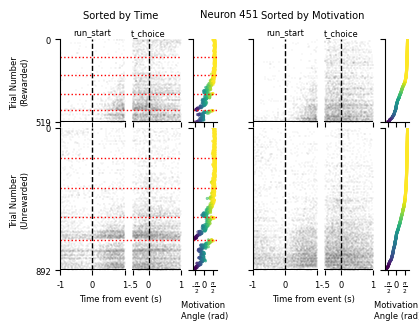

In [27]:
neuron_id = 451
# neuron_id = 26
# neuron_id = 274
# neuron_id = 103
# neuron_id = 475
# neuron_id = 2
# neuron_id = 8
# neuron_id = 212
# neuron_id = 64
# neuron_id = 7

flip_order = True

df_list = []
_df = trial_df.copy()
_df = _df[_df.prev_trial_reward == 1]
df_list.append(_df)
_df = trial_df.copy()
_df = _df[_df.prev_trial_reward == 0]
df_list.append(_df)
df_labels = ["Rewarded", "Unrewarded"]

mark_set = "B"
if mark_set == "A":
    figsize = (8,4)
    spike_marker_kwargs = dict(s=1, marker = "|",lw=.15,alpha=.6,color='k', rasterized=True)
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25, 2.5, ]
    range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]
elif mark_set == "B":
    figsize = (4.5,3)
    plt.rcParams["font.size"] = 6
    spike_marker_kwargs = dict(s=1, marker = "|",lw=.1,alpha=.4,color='k', rasterized=True)
    mark_list = [ "run_start", "t_choice", "t_poke", ]
    offset_list = [ -.5, 1.25,]
    range_list = [ (-1, 1), (-0.5, 1,)]

fig, ax_list_all = plt.subplots(figsize=figsize,ncols=5,nrows=2, width_ratios=[5,1,.5,5,1], sharey='row',
                            sharex='col',height_ratios=[len(df) for df in df_list], gridspec_kw={'hspace':0.05, 'wspace':0.2})


# spike_marker_kwargs = dict(s=1, marker = "|",lw=.15,alpha=.6,color='k', rasterized=True)
pc_marker_kwargs = dict(s=3, marker = "o",lw=.5,alpha=.6, rasterized=True)

for i_df, df in enumerate(df_list):

    ax_list = ax_list_all[i_df]

    xx_all = []
    yy_all = []
    cc_all = []
    angles = []

    for i, trial in enumerate(df.itertuples()):
        angles.append(trial.motivation)
        xx = []
        yy = []
        cc = []
        c=0
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            t_mark = getattr(trial, mark)
            t_start = t_mark + rng[0]
            t_end = t_mark + rng[1]
            ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
            ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

            xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
            yy.extend(np.ones(len(ind_neuron)))
            cc.extend([c]*len(ind_neuron))

        xx_all.append(xx)
        yy_all.append(yy)
        cc_all.append(cc)

    ## Plotting
    angle_sort = np.argsort(-np.array(angles))

    ax_sorted = ax_list[3]
    ax_unsorted = ax_list[0]
    pc_ax_sorted = ax_list[4]
    pc_ax_unsorted = ax_list[1]
    ax_list[2].set_axis_off()


    xx_plot = []
    yy_plot = []
    yy_unsorted = []
    xx_unsorted = []
    for i, trial in enumerate(angle_sort):
        xx = xx_all[trial]
        yy = yy_all[trial]
        # cc = cc_all[trial]
        if not np.isnan(angles[trial]):
            xx_plot.extend(xx)
            yy_plot.extend(np.array(yy)+i)
        yy_unsorted.extend(np.array(yy)+trial)
        xx_unsorted.extend(xx)
        # v = angles[trial]
        # c = plt.cm.viridis((v+np.pi/2)/np.pi)
        # pc_ax_sorted.scatter(v, i, s=10, color=c, alpha=.5)
        # pc_ax_sorted.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)
        # pc_ax_unsorted.scatter(v, trial, s=10, color=c, alpha=.5)
        # pc_ax_unsorted.plot([0, v], [trial, trial], color=c, alpha=.5, lw=.5, zorder = -10)

        # for j in range(2):
        #     v = trial_mot_pcs[trial][j]
        #     c = plt.cm.Dark2(motivation_pcs[j]/8)
        #     pc_ax.scatter(v, i, s=10, color=c, alpha=.5)
        #     pc_ax.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)

    v = np.array(angles)
    xx_v = np.arange(len(v))
    # v_color = plt.cm.viridis((v+np.pi/2)/np.pi)
    v_color = np.array([plt.cm.viridis((v_i+np.pi/2)/np.pi) for v_i in v])
    pc_ax_sorted.scatter(v[angle_sort], xx_v, **pc_marker_kwargs, c=v_color[angle_sort])
    pc_ax_unsorted.scatter(v, xx_v, **pc_marker_kwargs, c=v_color)
    for a in [pc_ax_sorted, pc_ax_unsorted]:
        a.spines[["top", "right"]].set_visible(False)
        if i_df == len(df_list)-1:
            a.set_xlabel("Motivation \nAngle (rad)")
        a.set_xticks([-np.pi/2, 0, np.pi/2], ["-$\\frac{\pi}{2}$", "0", "$\\frac{\pi}{2}$"])


    ax_sorted.scatter(xx_plot, yy_plot, **spike_marker_kwargs)
    ax_unsorted.scatter(xx_unsorted, yy_unsorted, **spike_marker_kwargs)
    ax_unsorted.set_ylim(0, len(df))

    for i_a, a in enumerate([ax_sorted, ax_unsorted]):
        a.spines[["top", "right","bottom"]].set_visible(False)
        ylim = a.get_ylim()
        ticks = []
        labels = []
        for mark, offset, rng in zip(mark_list, offset_list, range_list):
            lo = -1 if rng[0] < -.75 else rng[0]
            hi = 1 if rng[1] > 1 else rng[1]
            lo_txt = "-.5" if lo == -0.5 else "-1"
            hi_txt = ".5" if hi == 0.5 else "1"

            xx_ = np.array([lo, 0, hi])
            ticks.append(xx_ + offset)
            labels.append([lo_txt, "0", hi_txt])

            if flip_order:
                line_y = ylim[1]
            else:
                line_y = ylim[0]
            a.plot(xx_ + offset, [line_y] * len(xx_), color="k")
            a.axvline(offset, color="k", lw=1, ls="--")
            if i_df == 0:
                # a.text(offset - .1, ylim[1], mark, ha="left", va="bottom", rotation=30)
                if flip_order:
                    y_txt = ylim[0]-10
                else:
                    y_txt = ylim[1]+10
                a.text(offset, y_txt, mark, ha="center", va="bottom", rotation=0)


        ticks = np.concatenate(ticks)
        labels = np.concatenate(labels)
        a.set_xticks(ticks, labels)
        a.set_xlabel("Time from event (s)")

        a.set_ylim(ylim)
        a.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
        a.spines[["top", "right","bottom"]].set_visible(False)
    # pc_ax.spines[["top", "right",]].set_visible(False)
    fig.suptitle(f"Neuron {neuron_id}")
    # if i_df == len(df_list)-1:
        # pc_ax.set_xlabel("Motivation \nPC Values")

    trial_epoch = df["epoch"].values
    ind_switch = np.where(trial_epoch[1:] != trial_epoch[:-1])[0]+1
    for i in ind_switch:
        for a in [ax_unsorted, pc_ax_unsorted]:
            a.axhline(i+.5, color="r", alpha=1, lw=1,ls=':')


    ax_unsorted.set_ylabel(f"Trial Number \n({df_labels[i_df]})")
    ax_unsorted.set_yticks([0,  len(df)], )
    if i_df == 0:
        ax_unsorted.set_title("Sorted by Time", pad = 15)
        ax_sorted.set_title("Sorted by Motivation", pad = 15)

if flip_order:
    for a in ax_list_all[:,0]:
        ylim = a.get_ylim()
        a.set_ylim(ylim[1], ylim[0])


sub_dir = fig_dir / "sorted_by_motivation_split_by_reward"
sub_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams["svg.fonttype"] = 'none'
plt.rcParams["font.size"] = 8
fig.savefig(sub_dir / f"markeset_{mark_set}_neuron_{neuron_id}_sorted_by_motivation_split_by_reward.svg", dpi=300, bbox_inches="tight")

In [28]:
sub_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig5/mpfc_motivation_x_progression/wilbur_20210406_mpfc_HYBRID/sorted_by_motivation_split_by_reward')

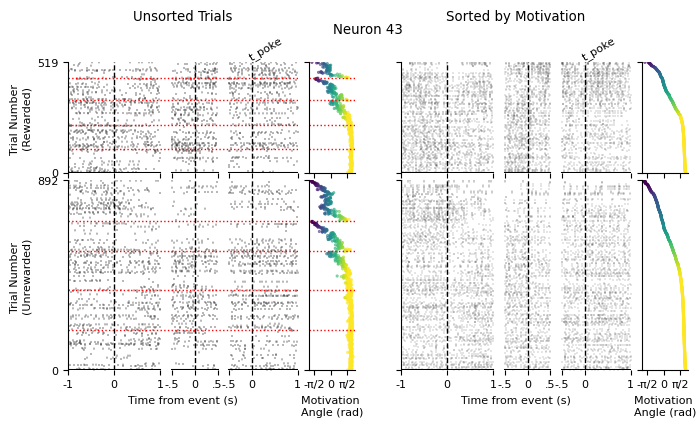

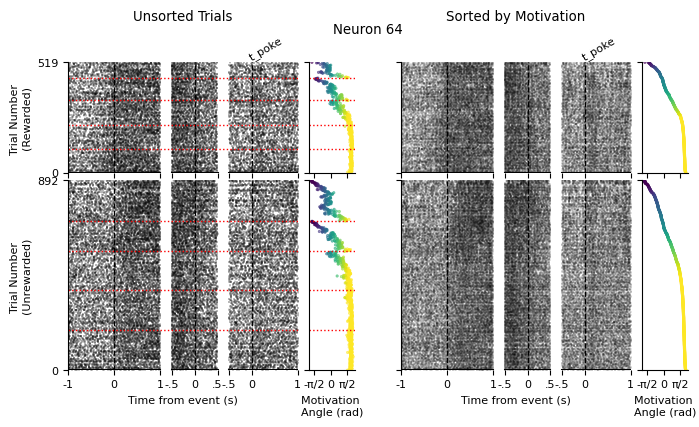

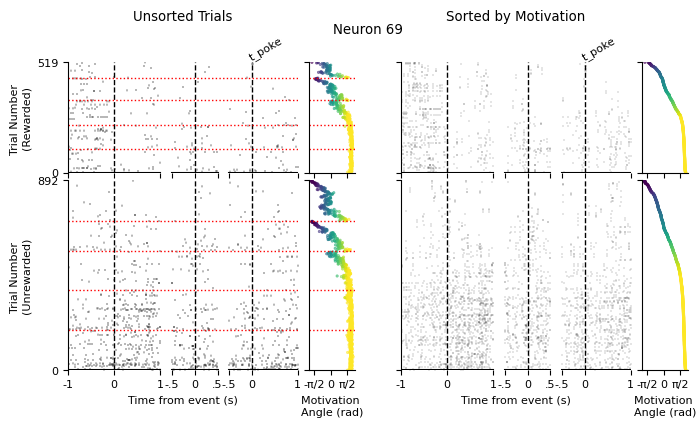

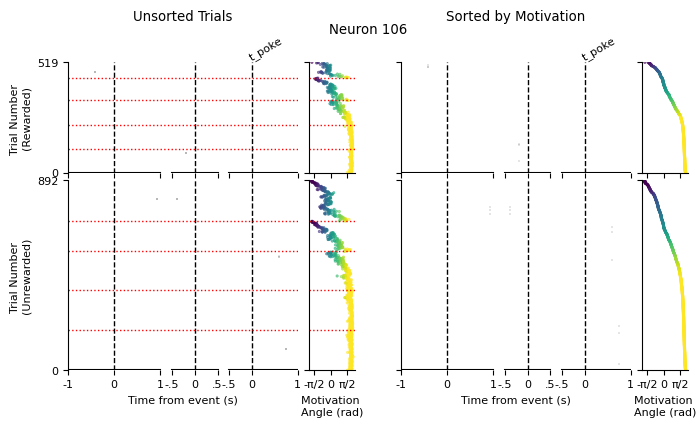

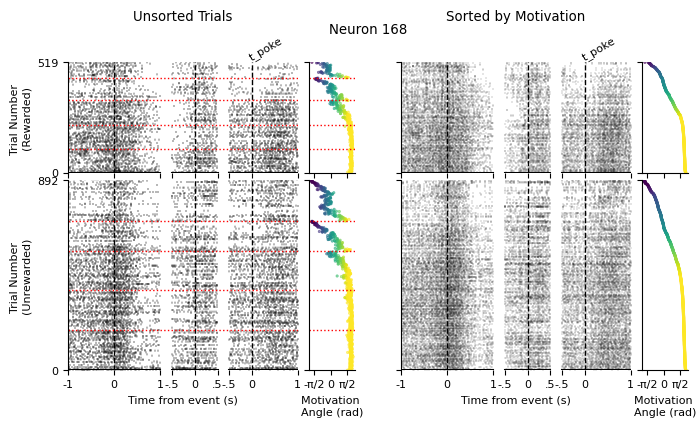

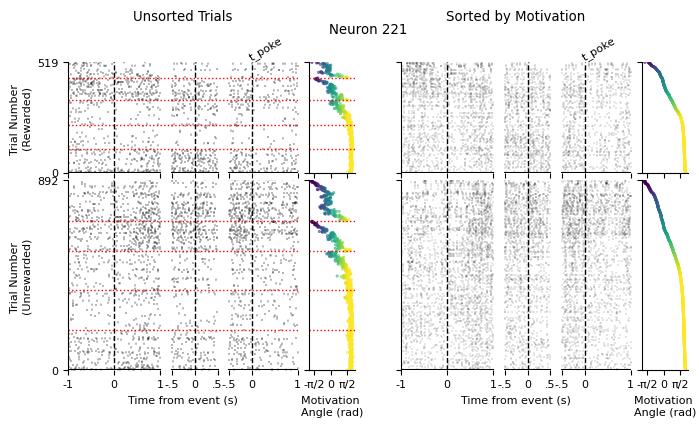

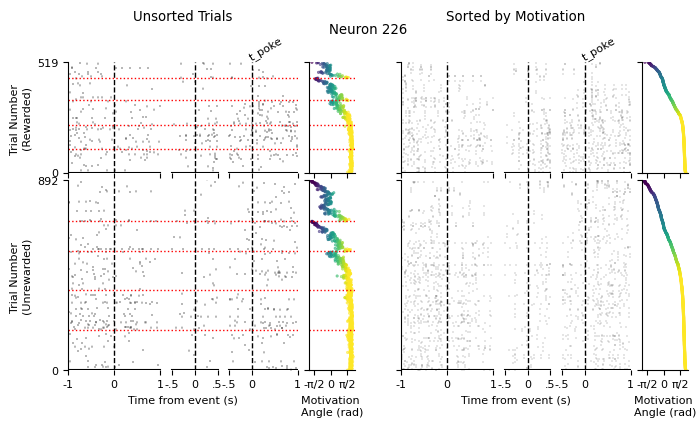

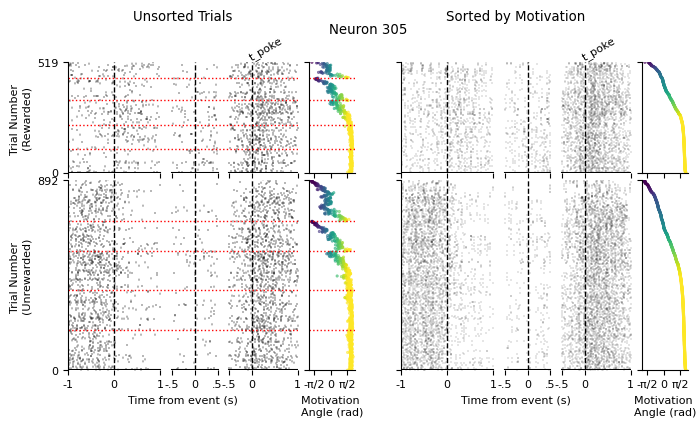

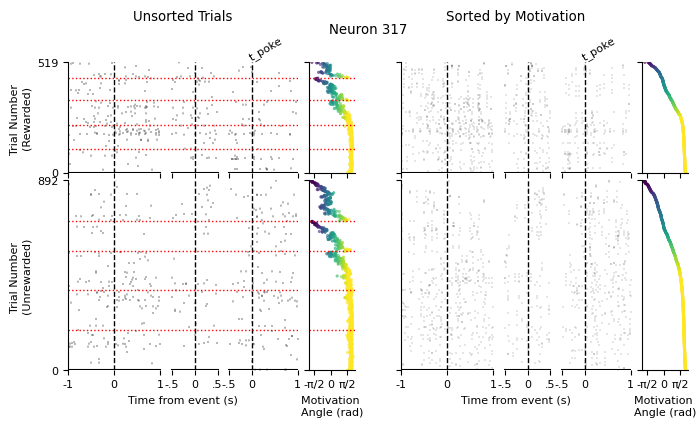

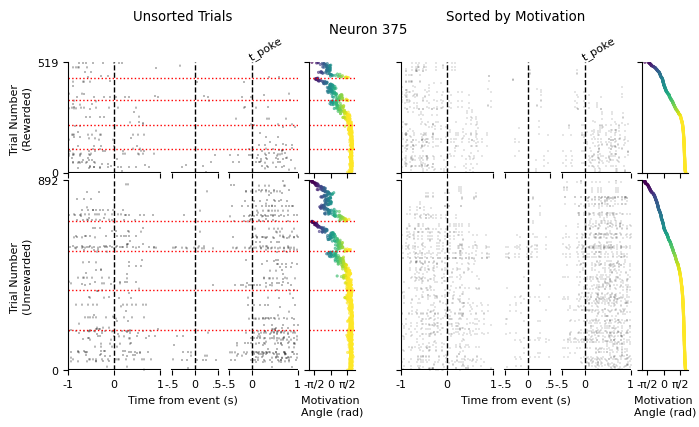

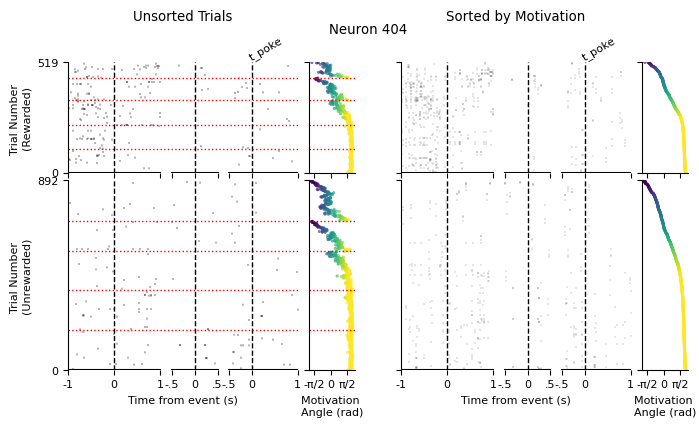

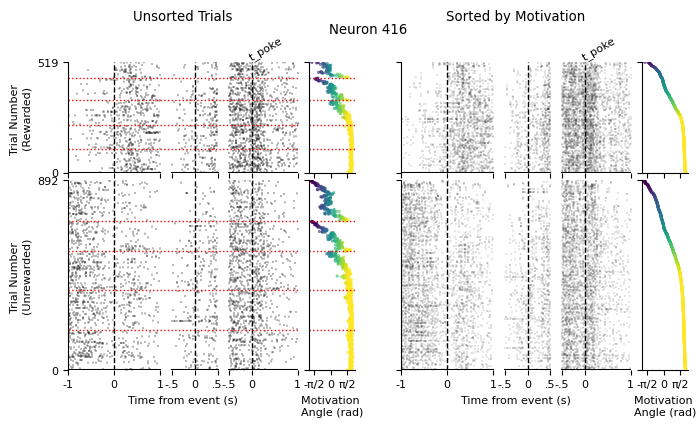

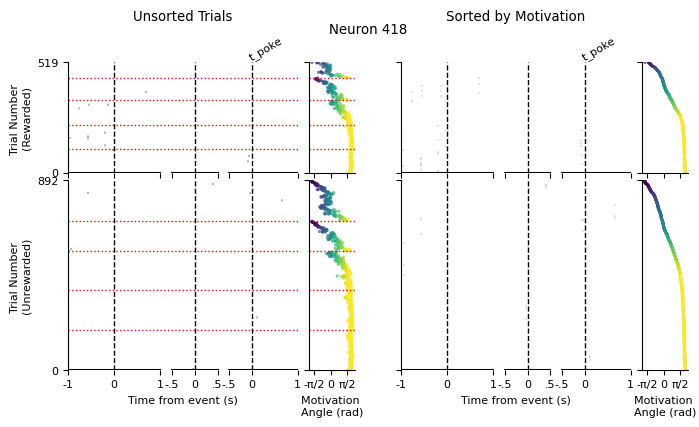

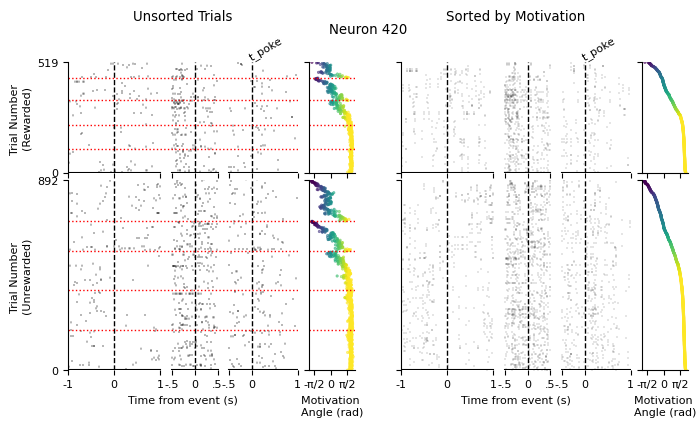

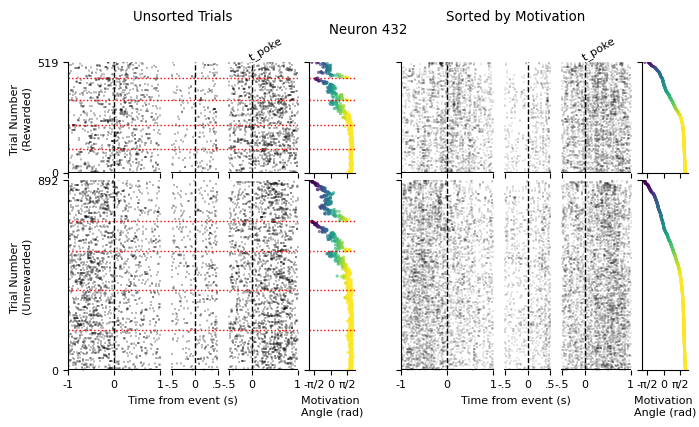

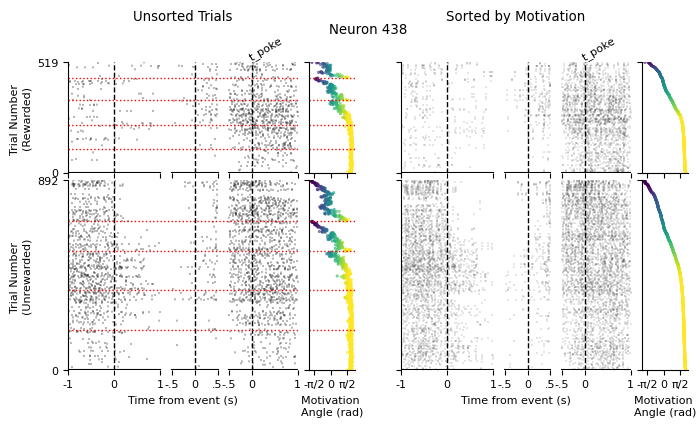

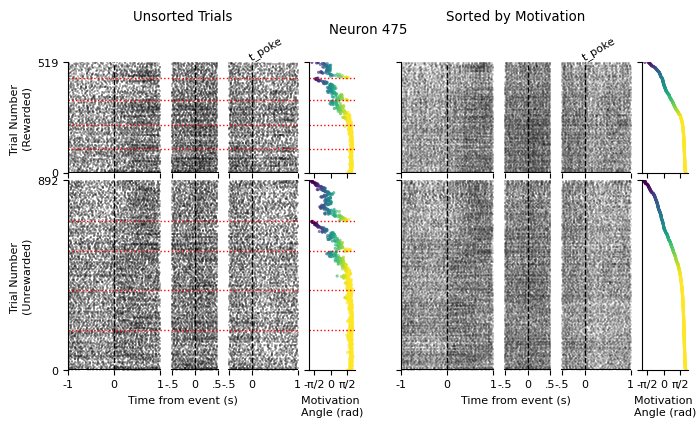

In [ ]:
neuron_list = [ 43,  64,  69, 106, 168, 221, 226, 305, 317, 375, 404, 416, 418,
       420, 432, 438, 475]

for neuron_id in neuron_list:

       df_list = []
       _df = trial_df.copy()
       _df = _df[_df.prev_trial_reward == 1]
       df_list.append(_df)
       _df = trial_df.copy()
       _df = _df[_df.prev_trial_reward == 0]
       df_list.append(_df)
       df_labels = ["Rewarded", "Unrewarded"]

       fig, ax_list_all = plt.subplots(figsize=(8,4),ncols=5,nrows=2, width_ratios=[5,1,.5,5,1], sharey='row',
                                   sharex='col',height_ratios=[len(df) for df in df_list], gridspec_kw={'hspace':0.05, 'wspace':0.1})

       mark_list = [ "run_start", "t_choice", "t_poke", ]
       offset_list = [ -.5, 1.25, 2.5, ]
       range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]

       for i_df, df in enumerate(df_list):

              ax_list = ax_list_all[i_df]

              xx_all = []
              yy_all = []
              cc_all = []
              angles = []

              for i, trial in enumerate(df.itertuples()):
                     angles.append(trial.motivation)
                     xx = []
                     yy = []
                     cc = []
                     for mark, offset, rng in zip(mark_list, offset_list, range_list):
                            t_mark = getattr(trial, mark)
                            t_start = t_mark + rng[0]
                            t_end = t_mark + rng[1]
                            ind_neuron = np.where(spikes[neuron_id] >= t_start)[0]
                            ind_neuron = ind_neuron[spikes[neuron_id][ind_neuron] <= t_end]

                            xx.extend(spikes[neuron_id][ind_neuron]-t_mark +offset)
                            yy.extend(np.ones(len(ind_neuron)))
                            cc.extend([c]*len(ind_neuron))

                            xx_all.append(xx)
                            yy_all.append(yy)
                            cc_all.append(cc)

              ## Plotting
              angle_sort = np.argsort(-np.array(angles))

              spike_marker_kwargs = dict(s=1, marker = "|",lw=.25,alpha=.6,color='k')
              pc_marker_kwargs = dict(s=3, marker = "o",lw=.5,alpha=.6)

              ax_sorted = ax_list[3]
              ax_unsorted = ax_list[0]
              pc_ax_sorted = ax_list[4]
              pc_ax_unsorted = ax_list[1]
              ax_list[2].set_axis_off()


              xx_plot = []
              yy_plot = []
              yy_unsorted = []
              xx_unsorted = []
              for i, trial in enumerate(angle_sort):
                     xx = xx_all[trial]
                     yy = yy_all[trial]
                     # cc = cc_all[trial]
                     if not np.isnan(angles[trial]):
                            xx_plot.extend(xx)
                            yy_plot.extend(np.array(yy)+i)
                     yy_unsorted.extend(np.array(yy)+trial)
                     xx_unsorted.extend(xx)
                     # v = angles[trial]
                     # c = plt.cm.viridis((v+np.pi/2)/np.pi)
                     # pc_ax_sorted.scatter(v, i, s=10, color=c, alpha=.5)
                     # pc_ax_sorted.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)
                     # pc_ax_unsorted.scatter(v, trial, s=10, color=c, alpha=.5)
                     # pc_ax_unsorted.plot([0, v], [trial, trial], color=c, alpha=.5, lw=.5, zorder = -10)

                     # for j in range(2):
                     #     v = trial_mot_pcs[trial][j]
                     #     c = plt.cm.Dark2(motivation_pcs[j]/8)
                     #     pc_ax.scatter(v, i, s=10, color=c, alpha=.5)
                     #     pc_ax.plot([0, v], [i, i], color=c, alpha=.5, lw=.5, zorder = -10)

              v = np.array(angles)
              xx_v = np.arange(len(v))
              # v_color = plt.cm.viridis((v+np.pi/2)/np.pi)
              v_color = np.array([plt.cm.viridis((v_i+np.pi/2)/np.pi) for v_i in v])
              pc_ax_sorted.scatter(v[angle_sort], xx_v, **pc_marker_kwargs, c=v_color[angle_sort])
              pc_ax_unsorted.scatter(v, xx_v, **pc_marker_kwargs, c=v_color)
              for a in [pc_ax_sorted, pc_ax_unsorted]:
                     a.spines[["top", "right"]].set_visible(False)
                     if i_df == len(df_list)-1:
                            a.set_xlabel("Motivation \nAngle (rad)")
                            a.set_xticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])


              ax_sorted.scatter(xx_plot, yy_plot, **spike_marker_kwargs)
              ax_unsorted.scatter(xx_unsorted, yy_unsorted, **spike_marker_kwargs)
              ax_unsorted.set_ylim(0, len(df))

              for i_a, a in enumerate([ax_sorted, ax_unsorted]):
                     a.spines[["top", "right","bottom"]].set_visible(False)
                     ylim = a.get_ylim()
                     ticks = []
                     labels = []
                     for mark, offset, rng in zip(mark_list, offset_list, range_list):
                            lo = -1 if rng[0] < -.75 else rng[0]
                            hi = 1 if rng[1] > 1 else rng[1]
                            lo_txt = "-.5" if lo == -0.5 else "-1"
                            hi_txt = ".5" if hi == 0.5 else "1"

                            xx_ = np.array([lo, 0, hi])
                            ticks.append(xx_ + offset)
                            labels.append([lo_txt, "0", hi_txt])

                            a.plot(xx_ + offset, [ylim[0]] * len(xx_), color="k")
                            a.axvline(offset, color="k", lw=1, ls="--")
                     if i_df == 0:
                            a.text(offset - .1, ylim[1], mark, ha="left", va="bottom", rotation=30)


                     ticks = np.concatenate(ticks)
                     labels = np.concatenate(labels)
                     a.set_xticks(ticks, labels)
                     a.set_xlabel("Time from event (s)")

                     a.set_ylim(ylim)
                     a.set_xlim(offset_list[0]+range_list[0][0], offset_list[-1]+range_list[-1][1])
                     a.spines[["top", "right","bottom"]].set_visible(False)
              pc_ax.spines[["top", "right",]].set_visible(False)
              fig.suptitle(f"Neuron {neuron_id}")
              if i_df == len(df_list)-1:
                     pc_ax.set_xlabel("Motivation \nPC Values")

              trial_epoch = df["epoch"].values
              ind_switch = np.where(trial_epoch[1:] != trial_epoch[:-1])[0]+1
              for i in ind_switch:
                     for a in [ax_unsorted, pc_ax_unsorted]:
                            a.axhline(i+.5, color="r", alpha=1, lw=1,ls=':')


              ax_unsorted.set_ylabel(f"Trial Number \n({df_labels[i_df]})")
              ax_unsorted.set_yticks([0,  len(df)], )
              if i_df == 0:
                     ax_unsorted.set_title("Unsorted Trials", pad = 30)
                     ax_sorted.set_title("Sorted by Motivation", pad = 30)


       sub_dir = fig_dir / "sorted_by_motivation_split_by_reward"
       sub_dir.mkdir(parents=True, exist_ok=True)
       plt.rcParams["svg.fonttype"] = 'none'
       plt.rcParams["font.size"] = 8
# fig.savefig(sub_dir / f"neuron_{neuron_id}_sorted_by_motivation_split_by_reward.svg", dpi=300, bbox_inches="tight")